In [1]:
import platform
if 'mac' in platform.platform():
    BASE_DIR = "/Users/USER/vrtopc/"
    DATA_DIR = "/media/data/vrtopc"
else:
    BASE_DIR = "/home/USER/vr_to_pc/"
    DATA_DIR = "/media/data/vrtopc"

import sys
sys.path.append(BASE_DIR)

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
exp_dir = "/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01"

In [4]:
loss_train = np.load(os.path.join(exp_dir, "loss_train.npy"))
loss_test = np.load(os.path.join(exp_dir, "loss_test.npy"))

inputs = []
outputs = []
labels = []

for file in os.listdir(os.path.join(exp_dir, 'test_examples')):
    if "input" in file:
        inputs.append(np.load(os.path.join(exp_dir, 'test_examples', file)))
    elif "output" in file:
        outputs.append(np.load(os.path.join(exp_dir, 'test_examples', file)))
    elif "label" in file:
        labels.append(np.load(os.path.join(exp_dir, 'test_examples', file)))

In [5]:
act_dir = os.path.join(exp_dir, 'act_adult_epoch1500')

rate_maps = np.load(os.path.join(act_dir, 'place', 'rate_maps.npy'))
selected_place_units = np.concatenate([
    np.load(os.path.join(act_dir, 'indices_place_cells.npy')),
    np.load(os.path.join(act_dir, 'indices_conjunctive_cells.npy'))
])
si_r = np.load(os.path.join(act_dir, 'place', 'si.npy'))
rate_maps_selected = rate_maps[selected_place_units]
si_r = si_r[selected_place_units]

polar_maps = np.load(os.path.join(act_dir, 'hd', 'polar_maps.npy'))
selected_hd_units = np.concatenate([
    np.load(os.path.join(act_dir, 'indices_hd_cells.npy')),
    np.load(os.path.join(act_dir, 'indices_conjunctive_cells.npy'))
])
rvl = np.load(os.path.join(act_dir, 'hd', 'rvl.npy'))
polar_maps_selected = polar_maps[selected_hd_units]
rvl = rvl[selected_hd_units]

In [6]:
bins_thet = np.linspace(-np.pi, np.pi, 60+1)
thetas_ticks = np.array(
    [np.mean([a, b]) for a, b in zip(bins_thet, bins_thet[1:])]
)

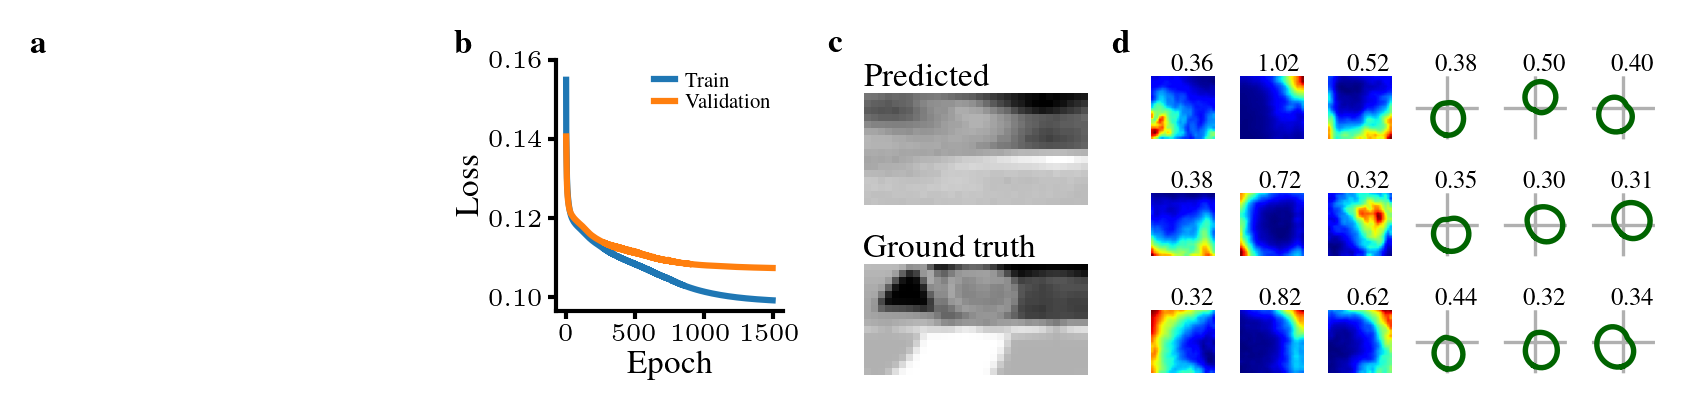

In [ ]:
np.random.seed(99)

plt.style.use(os.path.join(BASE_DIR, 'matplotlib_style.mplstyle'))

fig, axs = plt.subplots(1, 4, figsize=(5.5, 1.25), width_ratios=(0.24,0.16,0.20,0.40), dpi=300,  layout="constrained")
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{times}'
plt.rcParams['font.family'] = 'serif'

###############################################################
### PLOT 1 ####################################################
ax = axs.flat[0]
ax.annotate(
    r'\textbf{a}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-10, 0), textcoords='offset points',
    ha='right', va='bottom', fontweight='bold'
)
ax.set_axis_off()

###############################################################
### PLOT 2 ####################################################
ax = axs.flat[1]

ax.annotate(
    r'\textbf{b}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-20, 0), textcoords='offset points',
    ha='right', va='bottom', fontweight='bold'
)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

ax.plot(loss_train, label='Train')
ax.plot(loss_test, label='Validation')

ax.set_xticks(range(0, 1_501, 500))
# ax.set_xlim([-32, 26])
ax.set_yticks([0.10, 0.12, 0.14, 0.16])
# ax.set_ylim([-15, 10])
ax.spines[['right', 'top']].set_visible(False)

leg = ax.legend(
    loc='upper right',
    frameon=False, borderpad=0.1, labelspacing=0.1,
    handletextpad=0.5, handlelength=1,
)

###############################################################
### PLOT 3 ####################################################
ax = axs.flat[2]

gs_c = ax.get_subplotspec()
fig.delaxes(ax)

# Create a nested GridSpec with 2 rows and 1 column in the location of the original ax
nested_gs = gs_c.subgridspec(2, 1, hspace=0) # hspace controls vertical space

idx_picked = 0

# Add the top subplot using the nested GridSpec
axtop = fig.add_subplot(nested_gs[0, 0])
im_top = axtop.imshow(outputs[idx_picked], cmap='gray')
axtop.set_axis_off()
axtop.set_title('Predicted', pad=0.5, loc='left')
axtop.annotate(
    r'\textbf{c}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-5, 8), textcoords='offset points',
    ha='right', va='bottom', fontweight='bold'
)

axbottom = fig.add_subplot(nested_gs[1, 0])
im_bottom = axbottom.imshow(labels[idx_picked], cmap='gray')
axbottom.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
axbottom.set_xticks([])
axbottom.set_yticks([])
axbottom.set_title('Ground truth', pad=0.5, loc='left')
# axbottom.set_xlabel('Ground truth', labelpad=1, loc='left')

###############################################################
### PLOT 4 ####################################################
ax = axs.flat[3]
gs_c = ax.get_subplotspec()
fig.delaxes(ax)

# Create a nested GridSpec with 2 rows and 1 column in the location of the original ax
nested_gs = gs_c.subgridspec(3, 6, hspace=0.01, wspace=0) # hspace controls vertical space

pc_indices = np.random.choice(len(rate_maps_selected), size=9, replace=False)
for r in range(3):
    for c in range(3):
        ax = fig.add_subplot(nested_gs[r, c])
        if r==0 and c==0:
            ax.annotate(
                r'\textbf{d}', xy=(0, 1), xycoords='axes fraction',
                xytext=(-5, 4), textcoords='offset points',
                ha='right', va='bottom', fontweight='bold'
            )
        ax.set_title(f'{si_r[pc_indices[r*3+c]]:.2f}', loc='right', pad=0.02, fontsize=6)
        ax.imshow(rate_maps_selected[pc_indices[r*3+c]], cmap='jet')
        ax.set_axis_off()

hdc_indices = np.random.choice(len(polar_maps_selected), size=9, replace=False)
for r in range(3):
    for c in range(3):
        ax = fig.add_subplot(nested_gs[r, c+3], polar=True)
        pm = polar_maps_selected[hdc_indices[r*3+c]]

        max_radius = np.max(pm)
        padding = max_radius * 0.15

        ax.plot(
            np.append(thetas_ticks, thetas_ticks[0]), # we want to close the circle
            np.append(pm, pm[0]), # we want to close the circle
            c='darkgreen', zorder=5, lw=1.3
            # marker='o', ms=5, mfc='red'
        )
        ax.set_title(f'{rvl[hdc_indices[r*3+c]]:.2f}', loc='right', pad=0.02, fontsize=6)
        ax.set_xticklabels([]) # remove degrees indication
        ax.set_rticks([]) # add intensity indication
        ax.set_theta_direction(-1)
        ax.set_theta_zero_location('N') # move 0 to the north
        ax.set_rmax(max_radius + padding)
        ax.set_thetagrids([0, 90, 180, 270])
        ax.grid(True)
        ax.spines[['polar']].set_visible(False)


# plt.tight_layout()
fig.get_layout_engine().set(wspace=0.) #, hspace=0, wspace=0)

plt.savefig(os.path.join(BASE_DIR, 'paper_figures', 'figure2.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.show()